In [1]:
import os as os
import sys as sys
import numpy as np
import h5py as h5py
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.rcParams['xtick.labelsize'] = 16
matplotlib.rcParams['ytick.labelsize'] = 16
matplotlib.rcParams['axes.labelsize'] = 20

/home2/weiguang/.local/lib/python3.10/site-packages/mpl_toolkits/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
import caesar

In [3]:
data_or=np.zeros([324,5],dtype=np.float32) # Mhalo, Mbcg, r, g, u

for i in np.arange(1, 325):
    ds=caesar.load('/home2/weiguang/data6/CL300_Caesar/NewMDCLUSTER_%04d/Caesar_snap_128.hdf5'%i)
    data_or[i-1,0]=ds.halos[0].masses['total']
    data_or[i-1,1]=ds.halos[0].central_galaxy.masses['stellar']
    data_or[i-1,2]=ds.halos[0].central_galaxy.absmag['sdss_r']
    data_or[i-1,3]=ds.halos[0].central_galaxy.absmag['sdss_g']
    data_or[i-1,4]=ds.halos[0].central_galaxy.absmag['sdss_u']


yt : [INFO     ] 2026-06-01 14:35:11,657 Opening /home2/weiguang/data6/CL300_Caesar/NewMDCLUSTER_0001/Caesar_snap_128.hdf5
yt : [INFO     ] 2026-06-01 14:35:16,372 Found 2653 halos
yt : [INFO     ] 2026-06-01 14:35:28,317 Found 1781 galaxies
yt : [INFO     ] 2026-06-01 14:35:30,220 Opening /home2/weiguang/data6/CL300_Caesar/NewMDCLUSTER_0002/Caesar_snap_128.hdf5
yt : [INFO     ] 2026-06-01 14:35:35,010 Found 2311 halos
yt : [INFO     ] 2026-06-01 14:35:46,509 Found 1557 galaxies
yt : [INFO     ] 2026-06-01 14:35:48,199 Opening /home2/weiguang/data6/CL300_Caesar/NewMDCLUSTER_0003/Caesar_snap_128.hdf5
yt : [INFO     ] 2026-06-01 14:35:52,545 Found 2881 halos
yt : [INFO     ] 2026-06-01 14:36:04,554 Found 2344 galaxies
yt : [INFO     ] 2026-06-01 14:36:06,100 Opening /home2/weiguang/data6/CL300_Caesar/NewMDCLUSTER_0004/Caesar_snap_128.hdf5
yt : [INFO     ] 2026-06-01 14:36:09,535 Found 2796 halos
yt : [INFO     ] 2026-06-01 14:36:20,883 Found 1988 galaxies
yt : [INFO     ] 2026-06-01 14:3

In [6]:
data_hr=np.zeros([324,5],dtype=np.float32) # Mhalo, Mbcg, r, g, u
for i in np.arange(1, 325):
    ds=caesar.load('/home2/weiguang/data13/Caesar-THE300-HR/FoF/NewMDCLUSTER_%03d/Caesar_snap_128.hdf5'%i)
    data_hr[i-1,0]=ds.halos[0].masses['total']
    data_hr[i-1,1]=ds.halos[0].central_galaxy.masses['stellar']
    data_hr[i-1,2]=ds.halos[0].central_galaxy.absmag['sdss_r']
    data_hr[i-1,3]=ds.halos[0].central_galaxy.absmag['sdss_g']
    data_hr[i-1,4]=ds.halos[0].central_galaxy.absmag['sdss_u']

yt : [INFO     ] 2024-07-08 14:49:37,276 Opening /home2/weiguang/data13/Caesar-THE300-HR/FoF/NewMDCLUSTER_001/Caesar_snap_128.hdf5
yt : [INFO     ] 2024-07-08 14:49:38,112 Found 64051 halos
yt : [INFO     ] 2024-07-08 14:49:39,516 Found 10301 galaxies
yt : [INFO     ] 2024-07-08 14:49:39,739 Opening /home2/weiguang/data13/Caesar-THE300-HR/FoF/NewMDCLUSTER_002/Caesar_snap_128.hdf5
yt : [INFO     ] 2024-07-08 14:49:41,190 Found 62121 halos
yt : [INFO     ] 2024-07-08 14:49:41,939 Found 8690 galaxies
yt : [INFO     ] 2024-07-08 14:49:42,085 Opening /home2/weiguang/data13/Caesar-THE300-HR/FoF/NewMDCLUSTER_003/Caesar_snap_128.hdf5
yt : [INFO     ] 2024-07-08 14:49:42,687 Found 81077 halos
yt : [INFO     ] 2024-07-08 14:49:43,525 Found 13701 galaxies
yt : [INFO     ] 2024-07-08 14:49:43,739 Opening /home2/weiguang/data13/Caesar-THE300-HR/FoF/NewMDCLUSTER_004/Caesar_snap_128.hdf5
yt : [INFO     ] 2024-07-08 14:49:44,287 Found 72775 halos
yt : [INFO     ] 2024-07-08 14:49:44,981 Found 11028 ga

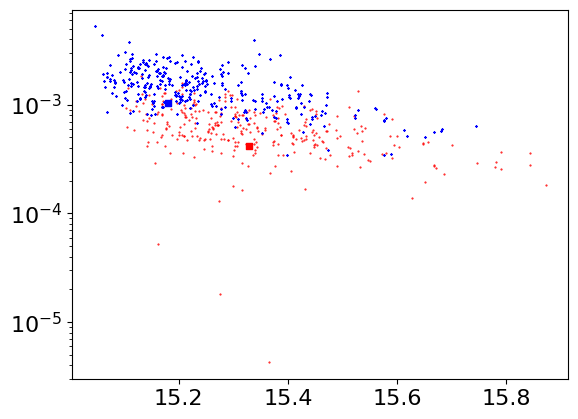

In [43]:
plt.scatter(np.log10(data_or[:,0]),(data_or[:,1]/data_or[:,0]),s=1, color='r', marker='.')
plt.scatter(np.log10(data_or[191,0]),(data_or[191,1]/data_or[191,0]),s=14, color='r', marker='s')
plt.scatter(np.log10(data_hr[:,0]),(data_hr[:,1]/data_hr[:,0]),s=1, color='b', marker='x')
plt.scatter(np.log10(data_hr[191,0]),(data_hr[191,1]/data_hr[191,0]),s=14, color='b', marker='s')
plt.yscale('log')

# AHF 

In [19]:
import glob

In [16]:
ahfp='/home2/weiguang/The300/data/catalogues/AHF/'

In [32]:
ahf_or=np.zeros([324,5],dtype=np.float32) # Mhalo, M*, Mg, R200c

for i in np.arange(1, 325):
    cn = 'NewMDCLUSTER_%04d'%i
    filen=ahfp+'GIZMO/'+cn+'/'+'GIZMO-'+cn+'.snap_128.z*.AHF_halos'
    fahf = glob.glob(filen)
    ahf = open(fahf[0],'r')
    count=0
    for line in ahf:
        if count==1:
            tmp=line.split(sep='\t')
            ahf_or[i-1, 3] = np.float64(tmp[11])
            ahf_or[i-1, 0] = np.float64(tmp[3])
            ahf_or[i-1, 1] = np.float64(tmp[64])
            ahf_or[i-1, 2] = np.float64(tmp[44])
            break
        count+=1

In [31]:
ahf_hr=np.zeros([324,5],dtype=np.float32) # Mhalo, M*, Mg, R200c

for i in np.arange(1, 325):
    cn = 'NewMDCLUSTER_%03d'%i
    filen=ahfp+'GIZMO_7k_R200c/'+cn+'/'+'GIZMO_7k-'+cn+'.snap_128.z*.AHF_halos'
    fahf = glob.glob(filen)
    if len(fahf)==1:
        ahf = open(fahf[0],'r')
        count=0
        for line in ahf:
            if count==1:
                tmp=line.split(sep='\t')
                ahf_hr[i-1, 3] = np.float64(tmp[11])
                ahf_hr[i-1, 0] = np.float64(tmp[3])
                ahf_hr[i-1, 1] = np.float64(tmp[64])
                ahf_hr[i-1, 2] = np.float64(tmp[44])
                break
            count+=1

/tmp/ipykernel_1482177/3117529787.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(ahf_hr[:,0]),(ahf_hr[:,1]/ahf_hr[:,0]),s=1, color='b', marker='x')
/tmp/ipykernel_1482177/3117529787.py:3: RuntimeWarning: invalid value encountered in divide
  plt.scatter(np.log10(ahf_hr[:,0]),(ahf_hr[:,1]/ahf_hr[:,0]),s=1, color='b', marker='x')


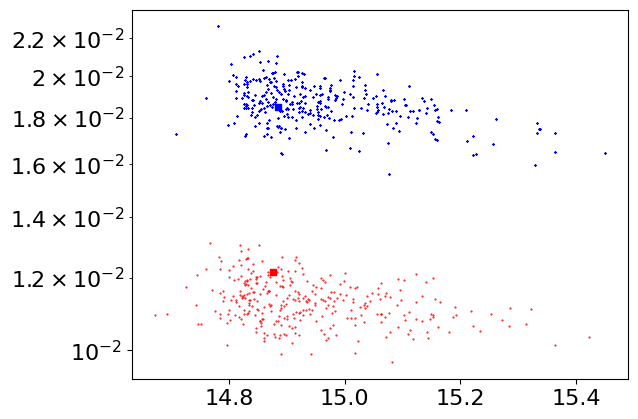

In [40]:
plt.scatter(np.log10(ahf_or[:,0]),(ahf_or[:,1]/ahf_or[:,0]),s=1, color='r', marker='.')
plt.scatter(np.log10(ahf_or[191,0]),(ahf_or[191,1]/ahf_or[191,0]),s=14, color='r', marker='s')
plt.scatter(np.log10(ahf_hr[:,0]),(ahf_hr[:,1]/ahf_hr[:,0]),s=1, color='b', marker='x')
plt.scatter(np.log10(ahf_hr[191,0]),(ahf_hr[191,1]/ahf_hr[191,0]),s=14, color='b', marker='s')
plt.yscale('log')

/tmp/ipykernel_1482177/2120046614.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(ahf_hr[:,0]),np.log10(ahf_hr[:,2]),s=1, color='b', marker='x')


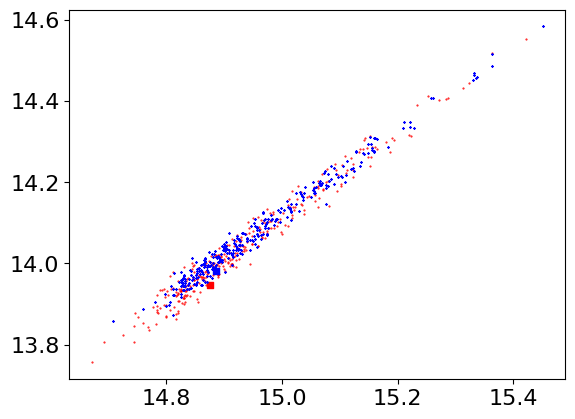

In [35]:
plt.scatter(np.log10(ahf_or[:,0]),np.log10(ahf_or[:,2]),s=1, color='r', marker='.')
plt.scatter(np.log10(ahf_or[191,0]),np.log10(ahf_or[191,2]),s=14, color='r', marker='s')
plt.scatter(np.log10(ahf_hr[:,0]),np.log10(ahf_hr[:,2]),s=1, color='b', marker='x')
plt.scatter(np.log10(ahf_hr[191,0]),np.log10(ahf_hr[191,2]),s=14, color='b', marker='s')

/tmp/ipykernel_1482177/3429424099.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(ahf_hr[:,0]),np.log10(ahf_hr[:,3]),s=1, color='b', marker='x')


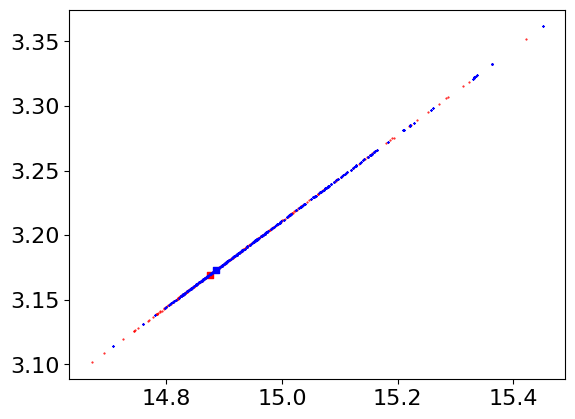

In [36]:
plt.scatter(np.log10(ahf_or[:,0]),np.log10(ahf_or[:,3]),s=1, color='r', marker='.')
plt.scatter(np.log10(ahf_or[191,0]),np.log10(ahf_or[191,3]),s=14, color='r', marker='s')
plt.scatter(np.log10(ahf_hr[:,0]),np.log10(ahf_hr[:,3]),s=1, color='b', marker='x')
plt.scatter(np.log10(ahf_hr[191,0]),np.log10(ahf_hr[191,3]),s=14, color='b', marker='s')